### **Symbolic Distillation of Neural Surrogates for Numerical Solvers**

*Mini-project by Hugo Robijns inspired by the work of Miles Cranmer and Liz Tan (PySR/SymTorch), and the principles of PhysicsX (Neural Surrogates/LPMs as a way of transforming classical numerical engineering processes).*

PhysicsX seeks to revolutionise engineering through the use of Large Physics Models, foundational engineering models trained on huge amounts of simulation and real-world data which can be used to provide inference *many orders of magnitudes faster* than equivalent numerical processes (FEM etc.). This allows real-time simulation and more thorough exploration of the design space.

Alongside this huge speed-up advantage:
- this approach is flexible (e.g. to different geometries/boundary conditions) instead of having to carry out a completely new numerical analysis each time (big cost advantage, only need to train these models once, although this training is large and expensive).
- functions much better in high dimensional work.

Some caveats/downsides/warning points are:
- this approach is strongly tied to its training data and these LPMs could therefore be biased (they're not inherently grounded to the maths in the way a numerical PDE solver is).
- large costs involved with improving/retraining this model if this is a huge computational job each time.
- although generalisation should be good, if it's far outside its training data scope, it might struggle where a numerical method will still be able to proceed (important for chaotic and non-linear systems).
- the models are black boxes, and therefore far less interpretable.

This notebook explores the final point, using recent work from the group where I'm carrying out my Master's project (https://astroautomata.com/), symbolic distillation of neural networks, and applying it to a neural surrogate to shed light on what is actually being 'learnt'. The proof-of-concept is the simple **Saint-Venant torsion problem** (Poisson's equation on a 2D disk).

To read more about the symbolic regression side:

_PySR_: https://ai.damtp.cam.ac.uk/pysr/v1.5.9/

_SymTorch_: https://symtorch.readthedocs.io/en/latest/
___

**Importing relevant dependancies**

Run (once, from the repo root):
```
python3 -m venv venv && source venv/bin/activate
pip install .
```

In [27]:
import pysr
import symtorch
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

___
**Data Generation: numerical solution of Saint-Venant's problem.**

A circular shaft of unit radius is twisted about its axis. Saint-Venant's semi-inverse method introduces the *Prandtl stress function* $\varphi$, which satisfies Poisson's equation over the cross-section:

$$\nabla^2 \varphi = -2G\Theta \quad \text{on } x^2+y^2 < 1, \qquad \varphi = 0 \text{ on } x^2+y^2 = 1$$

where $G$ is the shear modulus and $\Theta$ is the angle of twist per unit length. In dimensionless units ($G = \Theta = 1$) this becomes $\nabla^2 \varphi = -2$, with exact solution:

$$\varphi(x,y) = \frac{1 - x^2 - y^2}{2}$$

and shear stresses $\tau_{xz} = \partial\varphi/\partial y = -y$, $\tau_{yz} = -\partial\varphi/\partial x = x$; a pure rotational stress field, as expected.

This is a simple proof-of-concept example, but we could change/increase the complexity of a) the geometry/mesh (and use e.g. FEM to solve) and b) the PDE.

In [28]:
def solve_poisson_disk(n=64, iters=5000, f_val=-2.0):

    h = 2.0 / (n - 1)                  
    x = np.linspace(-1, 1, n)
    y = np.linspace(-1, 1, n)
    Xg, Yg  = np.meshgrid(x, y, indexing='ij')
    R2 = Xg**2 + Yg**2
    interior = R2 < 1.0              

    f = np.full((n, n), f_val)
    u = np.zeros((n, n))

    for _ in range(iters):
        u_new = np.zeros_like(u)
        u_new[1:-1, 1:-1] = 0.25 * (
            u[2:,  1:-1] + u[:-2, 1:-1] +
            u[1:-1, 2:]  + u[1:-1, :-2] -
            h**2 * f[1:-1, 1:-1]
        )
        u_new[~interior] = 0.0 # b.c.s 
        u = u_new

    return Xg, Yg, u, interior

Training points: (3096, 2),  Targets: (3096, 1)
Max FD error vs. exact solution: 0.01551  (O(h²) expected)


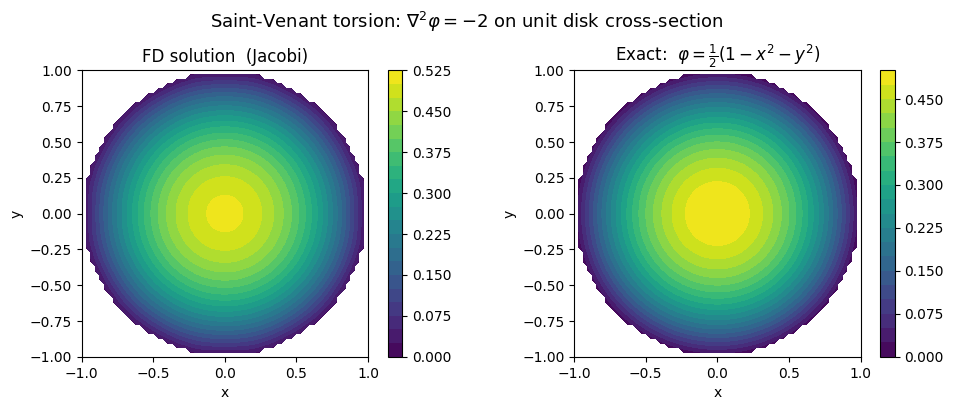

In [29]:
def generate_dataset(n=64, iters=5000):
    Xg, Yg, u_fd, interior = solve_poisson_disk(n=n, iters=iters)

    x_pts = Xg[interior]
    y_pts = Yg[interior]
    u_pts = u_fd[interior]

    X = np.stack([x_pts, y_pts], axis=1)
    Y = u_pts[:, None]                     
    return X, Y, Xg, Yg, u_fd, interior

X, Y, Xg, Yg, u_fd, interior = generate_dataset()
print(f"Training points: {X.shape},  Targets: {Y.shape}")

# validate FD solution against the known exact solution
u_exact   = np.where(interior, (1 - Xg**2 - Yg**2) / 2, np.nan)
u_fd_plot = np.where(interior, u_fd, np.nan)
max_err   = np.nanmax(np.abs(u_fd_plot - u_exact))
print(f"Max FD error vs. exact solution: {max_err:.5f}  (O(h²) expected)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, title in zip(
    axes,
    [u_fd_plot, u_exact],
    ['FD solution  (Jacobi)', r'Exact:  $\varphi = \frac{1}{2}(1 - x^2 - y^2)$']
):
    cf = ax.contourf(Xg, Yg, data, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title); ax.set_aspect('equal')
    ax.set_xlabel('x');  ax.set_ylabel('y')

plt.suptitle(r'Saint-Venant torsion: $\nabla^2\varphi = -2$ on unit disk cross-section', fontsize=13)
plt.tight_layout(); plt.show()

___
**Neural Surrogate: training an MLP on the simulated data.**

We use the simulated data to train a simple MLP. This MLP, once trained, will be able to provide near real-time inference of the same problem (the advantage of which becomes clear in larger and more complex scenarios).

Epoch    0,  MSE loss: 0.1092919
Epoch  100,  MSE loss: 0.0126974
Epoch  200,  MSE loss: 0.0030793
Epoch  300,  MSE loss: 0.0003246
Epoch  400,  MSE loss: 0.0002412
Epoch  500,  MSE loss: 0.0001961


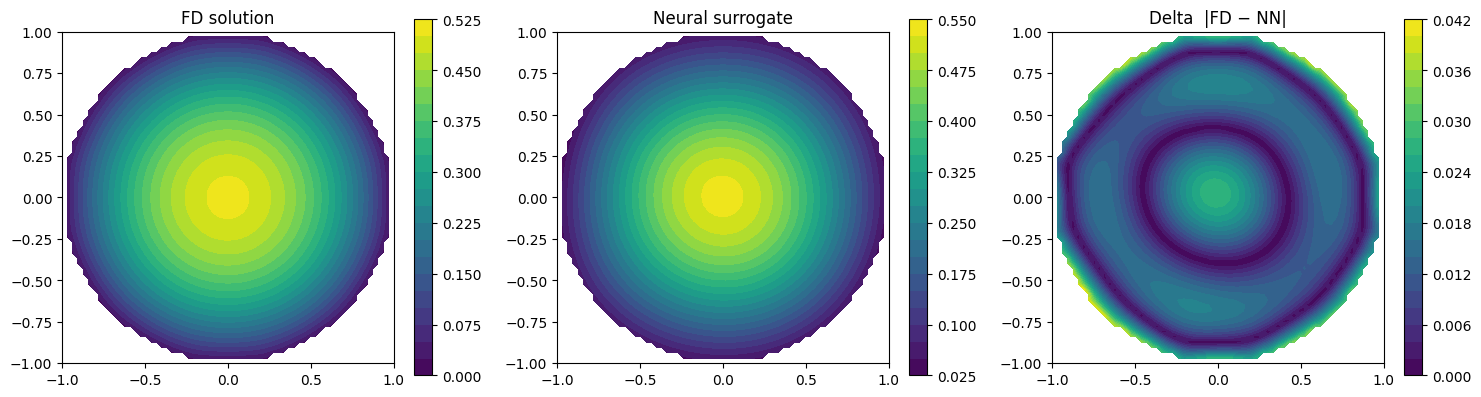

In [30]:
X_t = torch.tensor(X, dtype=torch.float32)
Y_t = torch.tensor(Y, dtype=torch.float32)

# two inputs (x, y); f is fixed so the surrogate only needs position
model = nn.Sequential(
    nn.Linear(2, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 1)
)

opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(501):
    pred = model(X_t)
    loss = ((pred - Y_t)**2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d},  MSE loss: {loss.item():.7f}")

# juliacall (loaded by pysr) breaks torch's numpy bridge, so convert via tolist()
with torch.no_grad():
    u_nn_pts = np.array(model(X_t).tolist()).flatten()

u_nn = np.full(Xg.shape, np.nan)
u_nn[interior] = u_nn_pts

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
panels = [
    (u_fd_plot, 'FD solution'),
    (u_nn, 'Neural surrogate'),
    (np.where(interior, np.abs(u_fd_plot - u_nn), np.nan), 'Delta  |FD − NN|'),
]
for ax, (data, title) in zip(axes, panels):
    cf = ax.contourf(Xg, Yg, data, levels=20, cmap='viridis')
    plt.colorbar(cf, ax=ax)
    ax.set_title(title); ax.set_aspect('equal')
plt.tight_layout(); plt.show()

_Interesting non-random structure to the final plot... due to non-linearity/basis mismatch?_

___
**Interpreting the Neural Surrogate: symbolic distillation with SymTorch.**

We now apply PySR-based symbolic regression to the trained neural network (not the raw data), distilling the black box into a human-readable formula. We expect:

$$\hat{\varphi}(x_1, x_2) \approx \frac{1}{2}(1 - x_1^2 - x_2^2)$$

In [31]:
def model_fn(x_numpy):
    x = torch.tensor(x_numpy, dtype=torch.float32)
    with torch.no_grad():
        return np.array(model(x).tolist())

sym_model = symtorch.SymbolicModel(model_fn)

sr_params = {
    'niterations': 500,
    'binary_operators': ['+', '-', '*'],
    'unary_operators': None,
    'maxsize': 15,
    'populations': 20,
}

# result = sym_model.distill(X, sr_params=sr_params)
# print(result)

Yippee! Highest score is complexity 11 (see SR_output/2D):
$$\hat{\varphi}(x_1, x_2) = (x_1^2 + x_2^2) \times -0.49 + 0.5 \approx \frac{1}{2}(1 - x_1^2 - x_2^2)$$
This is obviously a very simple example, but proof of concept!

In [32]:
import time

# FD solver: one full solve on the same grid
t0 = time.perf_counter()
solve_poisson_disk(n=64, iters=5000)
t_fd = time.perf_counter() - t0

# Neural surrogate: forward pass over the same interior points
X_query = torch.tensor(X, dtype=torch.float32)
t0 = time.perf_counter()
with torch.no_grad():
    _ = np.array(model(X_query).tolist())
t_nn = time.perf_counter() - t0

print(f"FD solver (5000 Jacobi iterations): {t_fd * 1e3:8.1f} ms")
print(f"Neural surrogate (forward pass): {t_nn * 1e3:8.2f} ms")
print(f"Speedup: {t_fd / t_nn:8.0f}×")

FD solver (5000 Jacobi iterations):    361.7 ms
Neural surrogate (forward pass):     4.80 ms
Speedup:       75×


Also a nifty speed-up... not bad! 

Lots of extensions from here: playing with different geometries, source terms (or PDEs all together), neural surrogate architectures, numerical techniques, introducing noise, inverse problems,  operator learning etc.